GESELECTEERDE MAP
Concentratie : 0
Hoek         : 5°
Map          : C:\Users\joris\OneDrive - HvA\Jaar 2\Projecten\Project 1\OCILLOSCOOP\Metingen\0\5

Aantal CSV-bestanden gevonden: 3
 - Newfile1_1_1.csv
 - Newfile1_1_2.csv
 - Newfile1_1_3.csv

BESTAND: Newfile1_1_1.csv
Aantal meetpunten: 876
Aantal pieken : 38
Aantal dalen  : 38
N             : 38
Δn            : 0.00101080


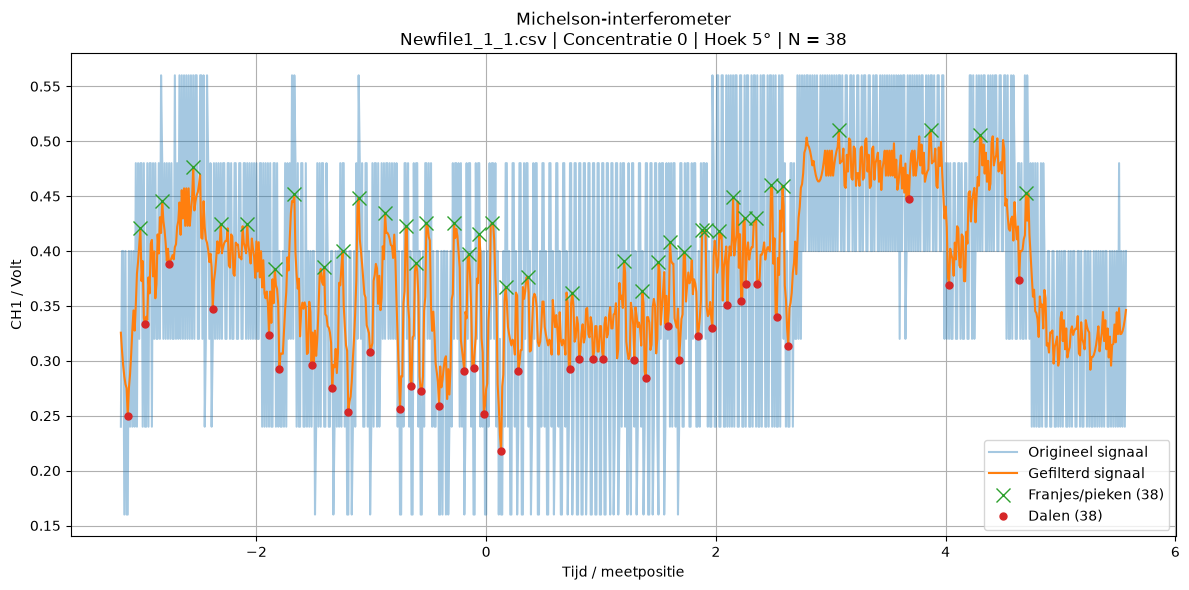


BESTAND: Newfile1_1_2.csv
Aantal meetpunten: 1400
Aantal pieken : 34
Aantal dalen  : 34
N             : 34
Δn            : 0.00090440


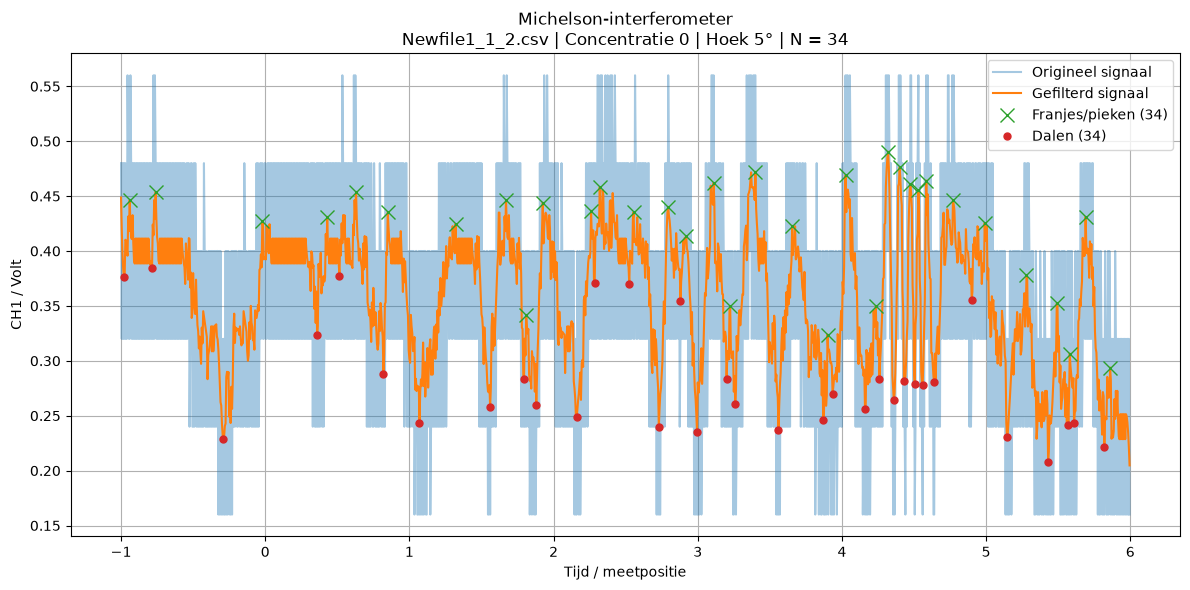


BESTAND: Newfile1_1_3.csv
Aantal meetpunten: 1400
Aantal pieken : 47
Aantal dalen  : 46
N             : 47
Δn            : 0.00125020


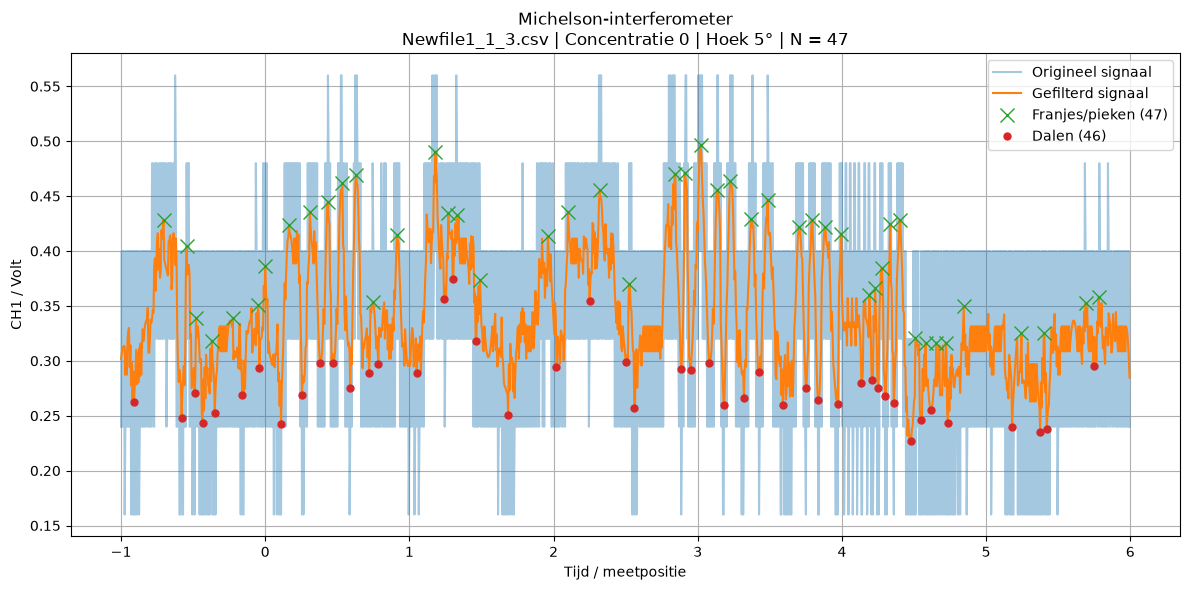


OVERZICHT ALLE METINGEN
Newfile1_1_1.csv          N =  38    Δn = 0.00101080
Newfile1_1_2.csv          N =  34    Δn = 0.00090440
Newfile1_1_3.csv          N =  47    Δn = 0.00125020


In [16]:
import csv
import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import find_peaks, savgol_filter


# INSTELLINGEN

# Hoofdmap waar alle metingen staan
HOOFDMAP = r"C:\Users\joris\OneDrive - HvA\Jaar 2\Projecten\Project 1\OCILLOSCOOP\Metingen"


# SELECTIE VAN DE MAP

CONCENTRATIE = "0"
HOEK = "5"


# Map waarin alle CSV-bestanden staan
MAP_METINGEN = os.path.join(
    HOOFDMAP,
    CONCENTRATIE,
    HOEK
)


# CONTROLEREN OF DE MAP BESTAAT

if not os.path.isdir(MAP_METINGEN):
    raise FileNotFoundError(
        f"\nMap niet gevonden:\n{MAP_METINGEN}"
    )


print("GESELECTEERDE MAP")
print(f"Concentratie : {CONCENTRATIE}")
print(f"Hoek         : {HOEK}°")
print(f"Map          : {MAP_METINGEN}")


# ALLE CSV-BESTANDEN VINDEN

csv_bestanden = sorted([
    bestand
    for bestand in os.listdir(MAP_METINGEN)
    if bestand.lower().endswith(".csv")
])


if len(csv_bestanden) == 0:
    raise FileNotFoundError(
        f"\nGeen CSV-bestanden gevonden in:\n{MAP_METINGEN}"
    )


print()
print(f"Aantal CSV-bestanden gevonden: {len(csv_bestanden)}")

for bestand in csv_bestanden:
    print(" -", bestand)


# CONSTANTEN

LAMBDA = 532e-9          # 532 nm
LENGTE_CUVET = 10e-3     # 10 mm


# Instellingen voor franjedetectie
MIN_AFSTAND = 3
PROMINENCE_FACTOR = 0.35


# Instellingen voor filter
FILTEREN = True
WINDOW_LENGTH = 11
POLYORDER = 2


# CSV INLEZEN

def lees_csv(bestand):

    x = []
    voltage = []

    start = None
    increment = None

    with open(
        bestand,
        "r",
        encoding="utf-8-sig"
    ) as f:

        reader = csv.reader(f)

        # Eerste regel
        header = next(reader)

        # Tweede regel bevat metadata
        metadata = next(reader)

        # Start en Increment proberen te lezen
        try:
            start = float(metadata[2])
            increment = float(metadata[3])
        except (ValueError, IndexError):
            pass

        # Rest van de data
        for row in reader:

            if len(row) < 2:
                continue

            try:
                nummer = int(row[0])
                waarde = float(row[1])
            except ValueError:
                continue

            x.append(nummer)
            voltage.append(waarde)

    x = np.array(x)
    voltage = np.array(voltage)

    # Echte tijdas maken als Start en Increment beschikbaar zijn
    if start is not None and increment is not None:
        tijd = start + x * increment
    else:
        tijd = x

    return tijd, voltage


# ALLE METINGEN ANALYSEREN

resultaten = []


for bestandsnaam in csv_bestanden:

    print()
    print(f"BESTAND: {bestandsnaam}")
    
    # Volledig pad
    csv_bestand = os.path.join(
        MAP_METINGEN,
        bestandsnaam
    )

    # DATA INLEZEN

    tijd, signaal = lees_csv(csv_bestand)

    print("Aantal meetpunten:", len(signaal))

    if len(signaal) < 10:
        print("Te weinig meetpunten - bestand overgeslagen.")
        continue


    # SIGNAAL FILTEREN

    signaal_origineel = signaal.copy()

    signaal_gefilterd = signaal.copy()

    if FILTEREN:

        window = WINDOW_LENGTH

        # Window mag niet groter zijn dan aantal meetpunten
        if window >= len(signaal_gefilterd):
            window = len(signaal_gefilterd) - 1

        # Window moet oneven zijn
        if window % 2 == 0:
            window -= 1

        # Window moet groter zijn dan polyorder
        if window <= POLYORDER:
            raise ValueError(
                f"WINDOW_LENGTH is te klein voor POLYORDER in {bestandsnaam}"
            )

        signaal_gefilterd = savgol_filter(
            signaal_gefilterd,
            window,
            POLYORDER
        )


    # NORMALISEREN

    signaal_ac = (
        signaal_gefilterd
        - np.mean(signaal_gefilterd)
    )

    amplitude = np.max(
        np.abs(signaal_ac)
    )

    prominence = (
        amplitude
        * PROMINENCE_FACTOR
    )


    # PIEKEN DETECTEREN

    pieken, eigenschappen = find_peaks(
        signaal_ac,
        distance=MIN_AFSTAND,
        prominence=prominence
    )


    # DALEN DETECTEREN

    dalen, eigenschappen_dalen = find_peaks(
        -signaal_ac,
        distance=MIN_AFSTAND,
        prominence=prominence
    )


    # AANTAL FRANJES

    aantal_pieken = len(pieken)
    aantal_dalen = len(dalen)

    # Pieken worden gebruikt als primaire telling
    N = aantal_pieken


    # BREKINGSINDEXVERSCHIL

    delta_n = (
        N * LAMBDA
        / (2 * LENGTE_CUVET)
    )


    # RESULTAAT OPSLAAN

    resultaten.append({
        "bestand": bestandsnaam,
        "pieken": aantal_pieken,
        "dalen": aantal_dalen,
        "N": N,
        "delta_n": delta_n
    })


    # RESULTAAT PRINTEN

    print("Aantal pieken :", aantal_pieken)
    print("Aantal dalen  :", aantal_dalen)
    print("N             :", N)
    print(f"Δn            : {delta_n:.8f}")


    # GRAFIEK MAKEN

    plt.figure(figsize=(12, 6))

    plt.plot(
        tijd,
        signaal_origineel,
        label="Origineel signaal",
        alpha=0.4
    )

    plt.plot(
        tijd,
        signaal_gefilterd,
        label="Gefilterd signaal"
    )

    plt.plot(
        tijd[pieken],
        signaal_gefilterd[pieken],
        "x",
        markersize=10,
        label=f"Franjes/pieken ({N})"
    )

    plt.plot(
        tijd[dalen],
        signaal_gefilterd[dalen],
        "o",
        markersize=5,
        label=f"Dalen ({aantal_dalen})"
    )

    plt.xlabel("Tijd / meetpositie")
    plt.ylabel("CH1 / Volt")

    plt.title(
        f"Michelson-interferometer\n"
        f"{bestandsnaam} | Concentratie {CONCENTRATIE} | "
        f"Hoek {HOEK}° | N = {N}"
    )

    plt.grid(True)
    plt.legend()

    plt.tight_layout()
    plt.show()


# OVERZICHT VAN ALLE RESULTATEN

print()
print("OVERZICHT ALLE METINGEN")

for resultaat in resultaten:

    print(
        f"{resultaat['bestand']:25s} "
        f"N = {resultaat['N']:3d}    "
        f"Δn = {resultaat['delta_n']:.8f}"
    )

In [19]:
import csv
import os

RESULTATEN_BESTAND = "resultaten.csv"


# CONTROLEREN OF DE ANALYSE IS UITGEVOERD

if "resultaten" not in globals():
    raise NameError(
        "De variabele 'resultaten' is niet gevonden. "
        "Run eerst de cel waarin alle CSV-bestanden worden geanalyseerd."
    )

if "CONCENTRATIE" not in globals():
    raise NameError(
        "CONCENTRATIE is niet gevonden. "
        "Run eerst de analysecel."
    )

if "HOEK" not in globals():
    raise NameError(
        "HOEK is niet gevonden. "
        "Run eerst de analysecel."
    )


# RESULTATEN OPSLAAN

bestand_bestaat = os.path.exists(
    RESULTATEN_BESTAND
)

with open(
    RESULTATEN_BESTAND,
    "a",
    newline="",
    encoding="utf-8"
) as bestand:

    writer = csv.writer(bestand)

    # Header alleen schrijven als het bestand nog niet bestaat
    if not bestand_bestaat:

        writer.writerow([
            "csv",
            "concentratie",
            "graden",
            "franjes"
        ])


    # Alle metingen opslaan
    for resultaat in resultaten:

        writer.writerow([
            resultaat["bestand"],
            CONCENTRATIE,
            HOEK,
            resultaat["N"]
        ])


# RESULTAAT TONEN

print()
print("ALLE METINGEN OPGESLAGEN")

print(f"Concentratie : {CONCENTRATIE}")
print(f"Hoek         : {HOEK}°")
print(f"Aantal metingen: {len(resultaten)}")

print()

for resultaat in resultaten:

    print(
        f"{resultaat['bestand']}  →  "
        f"N = {resultaat['N']}"
    )

print()
print(f"Opgeslagen in: {RESULTATEN_BESTAND}")


ALLE METINGEN OPGESLAGEN
Concentratie : 0
Hoek         : 5°
Aantal metingen: 3

Newfile1_1_1.csv  →  N = 38
Newfile1_1_2.csv  →  N = 34
Newfile1_1_3.csv  →  N = 47

Opgeslagen in: resultaten.csv


In [20]:
import csv
import os
import numpy as np


# BESTANDEN

# Bestand met alle individuele metingen
RESULTATEN_BESTAND = "resultaten.csv"

# Nieuw bestand met de gemiddelde en foutmarge per hoek
SAMENVATTING_BESTAND = "resultaten_gemiddelde.csv"


# CONTROLEREN OF RESULTATENBESTAND BESTAAT

if not os.path.exists(RESULTATEN_BESTAND):
    raise FileNotFoundError(
        f"{RESULTATEN_BESTAND} bestaat niet. "
        "Voer eerst de meetcel uit."
    )


# ALLE RUWE DATA INLEZEN

metingen = {}

with open(
    RESULTATEN_BESTAND,
    "r",
    newline="",
    encoding="utf-8"
) as bestand:

    reader = csv.DictReader(bestand)

    for rij in reader:

        graden = float(rij["graden"])
        franjes = float(rij["franjes"])

        # Maak een nieuwe lijst voor deze hoek
        # als deze nog niet bestaat
        if graden not in metingen:
            metingen[graden] = []

        # Voeg het aantal franjes toe
        metingen[graden].append(franjes)


# gemiddelde EN STANDAARDAFWIJKING BEREKENEN

samenvatting = []

for graden in sorted(metingen):

    franjes = np.array(metingen[graden])

    # gemiddelde
    # het gemiddelde wordt afgerond naar een geheel getal.
    gemiddelde = int(round(np.average(franjes)))

    # STANDAARDAFWIJKING
    # ddof=1 geeft de sample standard deviation.
    #
    # Dit is de foutmarge die wordt gebruikt voor de
    # spreiding van de herhaalde metingen.
    if len(franjes) > 1:
        foutmarge = np.std(franjes, ddof=1)
    else:
        foutmarge = 0.0

    # Voeg resultaat toe
    samenvatting.append([
        graden,
        gemiddelde,
        foutmarge
    ])


# NIEUW CSV-BESTAND MAKEN

with open(
    SAMENVATTING_BESTAND,
    "w",
    newline="",
    encoding="utf-8"
) as bestand:

    writer = csv.writer(bestand)

    # Header
    writer.writerow([
        "Graden",
        "franjes",
        "foutmarge"
    ])

    # Resultaten schrijven
    for graden, gemiddelde, foutmarge in samenvatting:

        writer.writerow([
            int(graden),
            gemiddelde,
            f"{foutmarge:.4f}"
        ])


# RESULTAAT TONEN

print("SAMENVATTING GEMAAKT")

for graden, gemiddelde, foutmarge in samenvatting:

    aantal_metingen = len(metingen[graden])

    print(
        f"{graden:g}°: "
        f"gemiddelde = {gemiddelde}, "
        f"stdev = {foutmarge:.4f}, "
        f"aantal metingen = {aantal_metingen}"
    )

print()
print(f"Bestand opgeslagen als:")
print(SAMENVATTING_BESTAND)

SAMENVATTING GEMAAKT
5°: gemiddelde = 40, stdev = 6.6583, aantal metingen = 3

Bestand opgeslagen als:
resultaten_gemiddelde.csv
